In [1]:
import os
import numpy as np
import pandas as pd
import math
import json
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial.distance import pdist, squareform
from datetime import timedelta
from itertools import product

In [2]:
### New##############

# --- Data Loading and Pre-processing ---

# Load datasets
population = pd.read_csv("population.csv")
cases = pd.read_csv("cases.csv")
movement = pd.read_csv("movement.csv")
prev_culls = pd.read_csv("prev_culls.csv")

# --- Date parsing (required for FOI alignment) ---
#cases['date_confirmed'] = pd.to_datetime(cases['date_confirmed'], errors='coerce')

cases["date_suspicious"] = pd.to_datetime(cases["date_suspicious"], errors="coerce")
cases["date_confirmed"]  = pd.to_datetime(cases["date_confirmed"], errors="coerce")
cases["cull_start"]      = pd.to_datetime(cases["cull_start"], errors="coerce")
cases["cull_end"]        = pd.to_datetime(cases["cull_end"], errors="coerce")

movement['date'] = pd.to_datetime(movement['date'], errors='coerce')
prev_culls['cull_start'] = pd.to_datetime(prev_culls['cull_start'], errors='coerce')

for df in [cases, prev_culls]:
    df["cull_start"] = pd.to_datetime(df["cull_start"], errors="coerce")
    df["cull_end"]   = pd.to_datetime(df["cull_end"], errors="coerce")

# --- Classify production types ---
# B2: broiler_2
# D : duck organic
# O : others
def classify_prod(row):
    if row['production'] == 'broiler_2':
        return 'B2'
    if row['species'] == 'duck' and row['production'] == 'organic':
        return 'D'
    return 'O'

population['prod3'] = population.apply(classify_prod, axis=1)

# --- Enforce consistent production ordering ---
prod_levels = ['B2', 'D', 'O']
population['prod3'] = pd.Categorical(
    population['prod3'],
    categories=prod_levels,
    ordered=True
)

# --- Sanity check ---
assert population['prod3'].notna().all(), "Some farms missing prod3 classification"
assert "cull_start" in cases.columns

population


C:\Users\hamme\AppData\Local\Temp\ipykernel_26148\258456426.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cases["date_suspicious"] = pd.to_datetime(cases["date_suspicious"], errors="coerce")
C:\Users\hamme\AppData\Local\Temp\ipykernel_26148\258456426.py:15: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cases["date_confirmed"]  = pd.to_datetime(cases["date_confirmed"], errors="coerce")
C:\Users\hamme\AppData\Local\Temp\ipykernel_26148\258456426.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cases["cull_start"]      = pd.to_datetime(cases["cull_start"], errors="coerce")
C:\Users\hamme\AppData\Local\Temp\ipykernel_26148\258456426.p

,farm_id,county,district,species,production,capacity,x,y,prod3
0,1,Allegheny,Cliffside Park,duck,conventional,13570,454041.272866,4.676745e+06,O
1,2,Allegheny,Rockleigh,chicken,broiler_2,1650,437886.164924,4.642867e+06,B2
2,3,Fulton,Roselle,chicken,broiler_2,1632,418430.342104,4.673373e+06,B2
3,4,Fulton,Hightstown,duck,organic,965,415527.794992,4.663552e+06,D
4,5,Fulton,Hulmeville,duck,conventional,14844,435731.287824,4.670470e+06,O
...,...,...,...,...,...,...,...,...,...
9155,9156,Susquehanna,Winfield,duck,conventional,14246,442573.893751,4.599033e+06,O
9156,9157,Luzerne,Fredon,chicken,layer,18932,474034.319271,4.504579e+06,O
9157,9158,Luzerne,Hardyston,chicken,broiler_2,4153,480834.831793,4.517927e+06,B2
9158,9159,Berks,Port Matilda,chicken,broiler_2,1811,456348.404620,4.559242e+06,B2


In [3]:
print(population['prod3'].value_counts())
print(movement['date'].min(), movement['date'].max())

prod3
O     5380
B2    2746
D     1034
Name: count, dtype: int64
2025-01-09 00:00:00 2026-12-02 00:00:00


In [4]:
# --- Simulation timeline ---

fit_end_date = pd.Timestamp("2026-02-13")
sim_start_date = pd.Timestamp("2025-12-22")
sim_end_date   = pd.Timestamp("2026-03-13")

sim_dates = pd.date_range(sim_start_date, sim_end_date)

In [5]:
counties_vec = sorted(population['county'].unique())

C = len(counties_vec)
P = len(prod_levels)
T = len(sim_dates)

# --- Aggregate farm counts by county and production ---
county_prod_farms = (
    population
    .groupby(['county', 'prod3'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=counties_vec, columns=prod_levels, fill_value=0)
    .values
)

C:\Users\hamme\AppData\Local\Temp\ipykernel_26148\489097044.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['county', 'prod3'])


In [6]:
# --- Model Parameters ---

# Within-county direct transmission
beta_within_p = {
    "B2": 0.25,
    "D":  0.15,
    "O":  0.20
}

# Environmental exposure
beta_env_p = {
    "B2": 0.25,
    "D":  0.14,
    "O":  0.30
}

# Environmental shedding
kappa_env_p = {
    "B2": 0.30,
    "D":  0.20,
    "O":  0.50
}

# Movement-based transmission (per unit volume)
beta_move_p = {
    "B2": 5e-5,
    "D":  3e-5,
    "O":  1e-5
}

# Disease progression
sigma = 1 / 3
gamma = 1 / 7

# Environmental decay
delta_env = 0.2

# --- Confinement ---
confinement_start = pd.Timestamp("2026-01-13")

# Reduce environmental exposure
conf_env_exp = {
    "B2": 0.95,
    "D":  0.95,
    "O": 1 #0.60
}

# Reduce environmental shedding
conf_env_shed = {
    "B2": 0.20,
    "D":  0.20,
    "O":  0.70
}

# Reduce movements
conf_move = {
    "B2": 0.10,
    "D": 0.20,
    "O":  0.50
}



In [7]:
beta_w_arr   = np.array([beta_within_p[p] for p in prod_levels])
beta_e_arr   = np.array([beta_env_p[p]    for p in prod_levels])
kappa_e_arr  = np.array([kappa_env_p[p]   for p in prod_levels])
beta_m_arr   = np.array([beta_move_p[p]   for p in prod_levels])

conf_exp_arr  = np.array([conf_env_exp[p]  for p in prod_levels])
conf_shed_arr = np.array([conf_env_shed[p] for p in prod_levels])
conf_move_arr = np.array([conf_move[p]     for p in prod_levels])


In [8]:
# --- Index maps ---
county_idx = {c: i for i, c in enumerate(counties_vec)}
prod_idx = {p: i for i, p in enumerate(prod_levels)}

# --- Farm lookup ---
farm_lookup = population.set_index("farm_id")[["county", "prod3"]]
assert farm_lookup.index.is_unique



In [9]:
# --- Reactive culling: remove ONLY when completed ---
reactive_culls = np.zeros((C, P, T), dtype=int)

for _, r in cases.iterrows():

    if r.cull_status != "completed":
        continue
    if pd.isna(r.cull_end):
        continue
    if r.farm_id not in farm_lookup.index:
        continue
    if r.cull_end not in sim_dates:
        continue

    farm = farm_lookup.loc[r.farm_id]
    c = county_idx[farm.county]
    p = prod_idx[farm.prod3]
    t = np.where(sim_dates == r.cull_end)[0][0]

    reactive_culls[c, p, t] += 1

In [10]:

# --- Preventive culling: remove ONLY when completed ---
preventive_culls = np.zeros((C, P, T), dtype=int)

for _, r in prev_culls.iterrows():

    if r.cull_status != "completed":
        continue
    if pd.isna(r.cull_end):
        continue
    if r.farm_id not in farm_lookup.index:
        continue
    if r.cull_end not in sim_dates:
        continue

    farm = farm_lookup.loc[r.farm_id]
    c = county_idx[farm.county]
    p = prod_idx[farm.prod3]
    t = np.where(sim_dates == r.cull_end)[0][0]

    preventive_culls[c, p, t] += 1

In [11]:
print("Detected farms:", cases.shape[0])
print("Completed reactive culls:", reactive_culls.sum())
print("Completed preventive culls:", preventive_culls.sum())

print("Planned or in-progress (cases):",
      (cases.cull_status != "completed").sum())

print("Planned or in-progress (prev_culls):",
      (prev_culls.cull_status != "completed").sum())
print("First reactive cull day:", np.where(reactive_culls.sum(axis=(0,1)) > 0)[0][0])

Detected farms: 466
Completed reactive culls: 452
Completed preventive culls: 48
Planned or in-progress (cases): 14
Planned or in-progress (prev_culls): 21
First reactive cull day: 3


In [12]:
# --- Movement tensor ---
# Shape: (time, county_from, county_to, production)
movement_tensor = np.zeros((T, C, C, P))

for _, r in movement.iterrows():

    if r.date < sim_start_date or r.date > sim_end_date:
        continue
    if r.source_farm not in farm_lookup.index:
        continue
    if r.dest_farm not in farm_lookup.index:
        continue

    t_idx = np.where(sim_dates == r.date)[0]
    if len(t_idx) == 0:
        continue
    t = t_idx[0]

    src = farm_lookup.loc[r.source_farm]
    dst = farm_lookup.loc[r.dest_farm]

    if src.county not in county_idx or dst.county not in county_idx:
        continue
    if src.prod3 not in prod_idx:
        continue

    c_from = county_idx[src.county]
    c_to   = county_idx[dst.county]
    p      = prod_idx[src.prod3]

    movement_tensor[t, c_from, c_to, p] += r.volume

In [13]:
def run_seir_county_prod_realistic(seed=None):

    if seed is not None:
        np.random.seed(seed)

    S = np.zeros((C, P, T), int)
    E = np.zeros_like(S)
    I = np.zeros_like(S)
    R = np.zeros_like(S)
    Env = np.zeros((C, T))

    S[:, :, 0] = county_prod_farms

    # --- Seed observed cases ---
    for _, r in cases.iterrows():
        if r.farm_id not in farm_lookup.index:
            continue
        if r.date_confirmed not in sim_dates:
            continue

        row = farm_lookup.loc[r.farm_id]
        c = county_idx[row.county]
        p = prod_idx[row.prod3]
        t = np.where(sim_dates == r.date_confirmed)[0][0]

        if S[c, p, t] > 0:
            S[c, p, t] -= 1
            I[c, p, t] += 1

    # --- Background seeding ---
    for c in range(C):
        for p in range(P):
            if I[c, p, 0] == 0:
                k = min(np.random.poisson(0.5), S[c, p, 0])
                S[c, p, 0] -= k
                I[c, p, 0] += k

    # --- Time loop ---
    for t in range(T - 1):

        St, Et, It, Rt = S[:, :, t], E[:, :, t], I[:, :, t], R[:, :, t]
        Env_t = Env[:, t]

        if sim_dates[t] >= confinement_start:
            c_exp  = conf_exp_arr
            c_shed = conf_shed_arr
            c_mov  = conf_move_arr
        else:
            c_exp  = np.ones(P)
            c_shed = np.ones(P)
            c_mov  = np.ones(P)

        # --- FOI ---
        force_local = beta_w_arr * It
        force_env = beta_e_arr * Env_t[:, None] * c_exp

        # Movement FOI
        prev = It / (county_prod_farms + 1e-6)
        M_t = movement_tensor[t]

        force_move = np.zeros((C, P))
        for p in range(P):
            force_move[:, p] = beta_m_arr[p] * (
                M_t[:, :, p].T @ prev[:, p]
            )

        force_move *= c_mov

        force_total = force_local + force_env + force_move

        # --- Transitions ---
        new_E = np.random.poisson(
            force_total * St / (county_prod_farms + 1e-6)
        )
        new_E = np.minimum(new_E, St)

        new_I = np.random.binomial(Et, sigma)
        new_R = np.random.binomial(It, gamma)

        S[:, :, t+1] = St - new_E
        E[:, :, t+1] = Et + new_E - new_I
        I[:, :, t+1] = It + new_I - new_R
        R[:, :, t+1] = Rt + new_R

        Env[:, t+1] = (
            Env_t * (1 - delta_env)
            + (kappa_e_arr * c_shed * It).sum(axis=1)
        )

    return {"I": I, "R": R, "Env": Env}

In [14]:
out = run_seir_county_prod_realistic(seed=0)
print("Remaining farms:",
      county_prod_farms.sum() -
      (reactive_culls.sum() + preventive_culls.sum()))

print("Final infections:",
      out["I"][:, :, -1].sum())

Remaining farms: 8660
Final infections: 4


In [15]:
def run_ensemble(n_runs=200, base_seed=1234):
    """
    Run an ensemble of stochastic SEIR-B simulations
    using the corrected OPTION A culling logic.
    """
    I_ens = np.zeros((n_runs, C, P, T), dtype=np.int32)
    R_ens = np.zeros_like(I_ens)
    Env_ens = np.zeros((n_runs, C, T), dtype=float)

    for i in range(n_runs):
        out = run_seir_county_prod_realistic(seed=base_seed + i)
        I_ens[i] = out["I"]
        R_ens[i] = out["R"]
        Env_ens[i] = out["Env"]

        if (i + 1) % 20 == 0:
            print(f"Completed run {i + 1}/{n_runs}")

    return {
        "I": I_ens,
        "R": R_ens,
        "Env": Env_ens
    }

ensemble = run_ensemble(n_runs=300, base_seed=2026)

Completed run 20/300
Completed run 40/300
Completed run 60/300
Completed run 80/300
Completed run 100/300
Completed run 120/300
Completed run 140/300
Completed run 160/300
Completed run 180/300
Completed run 200/300
Completed run 220/300
Completed run 240/300
Completed run 260/300
Completed run 280/300
Completed run 300/300


In [16]:


# Aggregate infections over county and production
I_total_time = ensemble["I"].sum(axis=(1, 2))  # (runs, time)

df_total = pd.DataFrame({
    "date": sim_dates,
    "I_mean": I_total_time.mean(axis=0),
    "I_lower_2p5": np.percentile(I_total_time, 2.5, axis=0),
    "I_upper_97p5": np.percentile(I_total_time, 97.5, axis=0)
})

df_total.to_csv("ensemble_total_infections_timeseries.csv", index=False)

In [17]:
rows = []

for p, prod in enumerate(prod_levels):
    I_pt = ensemble["I"][:, :, p, :].sum(axis=1)  # (runs, time)

    rows.append(
        pd.DataFrame({
            "date": sim_dates,
            "production": prod,
            "I_mean": I_pt.mean(axis=0),
            "I_lower_2p5": np.percentile(I_pt, 2.5, axis=0),
            "I_upper_97p5": np.percentile(I_pt, 97.5, axis=0)
        })
    )

df_by_prod = pd.concat(rows, ignore_index=True)
df_by_prod.to_csv("ensemble_infections_by_production.csv", index=False)


In [18]:
# Ensemble mean over runs
I_mean_county = ensemble["I"].mean(axis=0)  # (county, prod, time)

records = []

for c, county in enumerate(counties_vec):
    for p, prod in enumerate(prod_levels):
        for t, date in enumerate(sim_dates):
            records.append({
                "county": county,
                "production": prod,
                "date": date,
                "I_mean": I_mean_county[c, p, t]
            })

df_county = pd.DataFrame(records)
df_county.to_csv("ensemble_county_production_mean.csv", index=False)


In [19]:
print("Mean final infections:",
      ensemble["I"][:, :, :, -1].sum(axis=(1, 2)).mean())


Mean final infections: 14.42


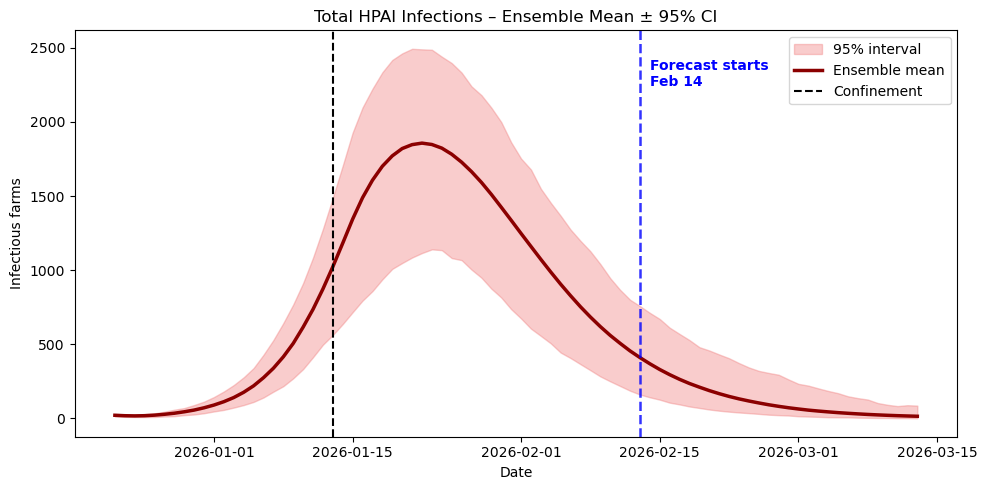

In [20]:
# --- Aggregate total infectious farms over time ---
# ensemble["I"]: (runs, counties, productions, time)

I_total_time = ensemble["I"].sum(axis=(1, 2))  # (runs, time)

I_mean = I_total_time.mean(axis=0)
I_lo = np.percentile(I_total_time, 2.5, axis=0)
I_hi = np.percentile(I_total_time, 97.5, axis=0)

# --- Plot ---
plt.figure(figsize=(10, 5))

plt.fill_between(
    sim_dates,
    I_lo,
    I_hi,
    color="lightcoral",
    alpha=0.4,
    label="95% interval"
)

plt.plot(
    sim_dates,
    I_mean,
    color="darkred",
    lw=2.5,
    label="Ensemble mean"
)

# Confinement
plt.axvline(
    confinement_start,
    color="black",
    linestyle="--",
    lw=1.5,
    label="Confinement"
)

# Forecast start (fit end)
plt.axvline(
    fit_end_date,
    color="blue",
    linestyle="--",
    alpha=0.8,
    lw=1.8
)

# Annotation
plt.text(
    fit_end_date + pd.Timedelta(days=1),
    I_hi.max() * 0.9,
    "Forecast starts\nFeb 14",
    color="blue",
    fontweight="bold"
)

plt.ylabel("Infectious farms")
plt.xlabel("Date")
plt.title("Total HPAI Infections – Ensemble Mean ± 95% CI")

plt.legend()
plt.tight_layout()
plt.savefig("Total_Infection.png", dpi=300)
plt.show()

In [21]:
I_mean = I_mean.max()
I_mean

1857.27

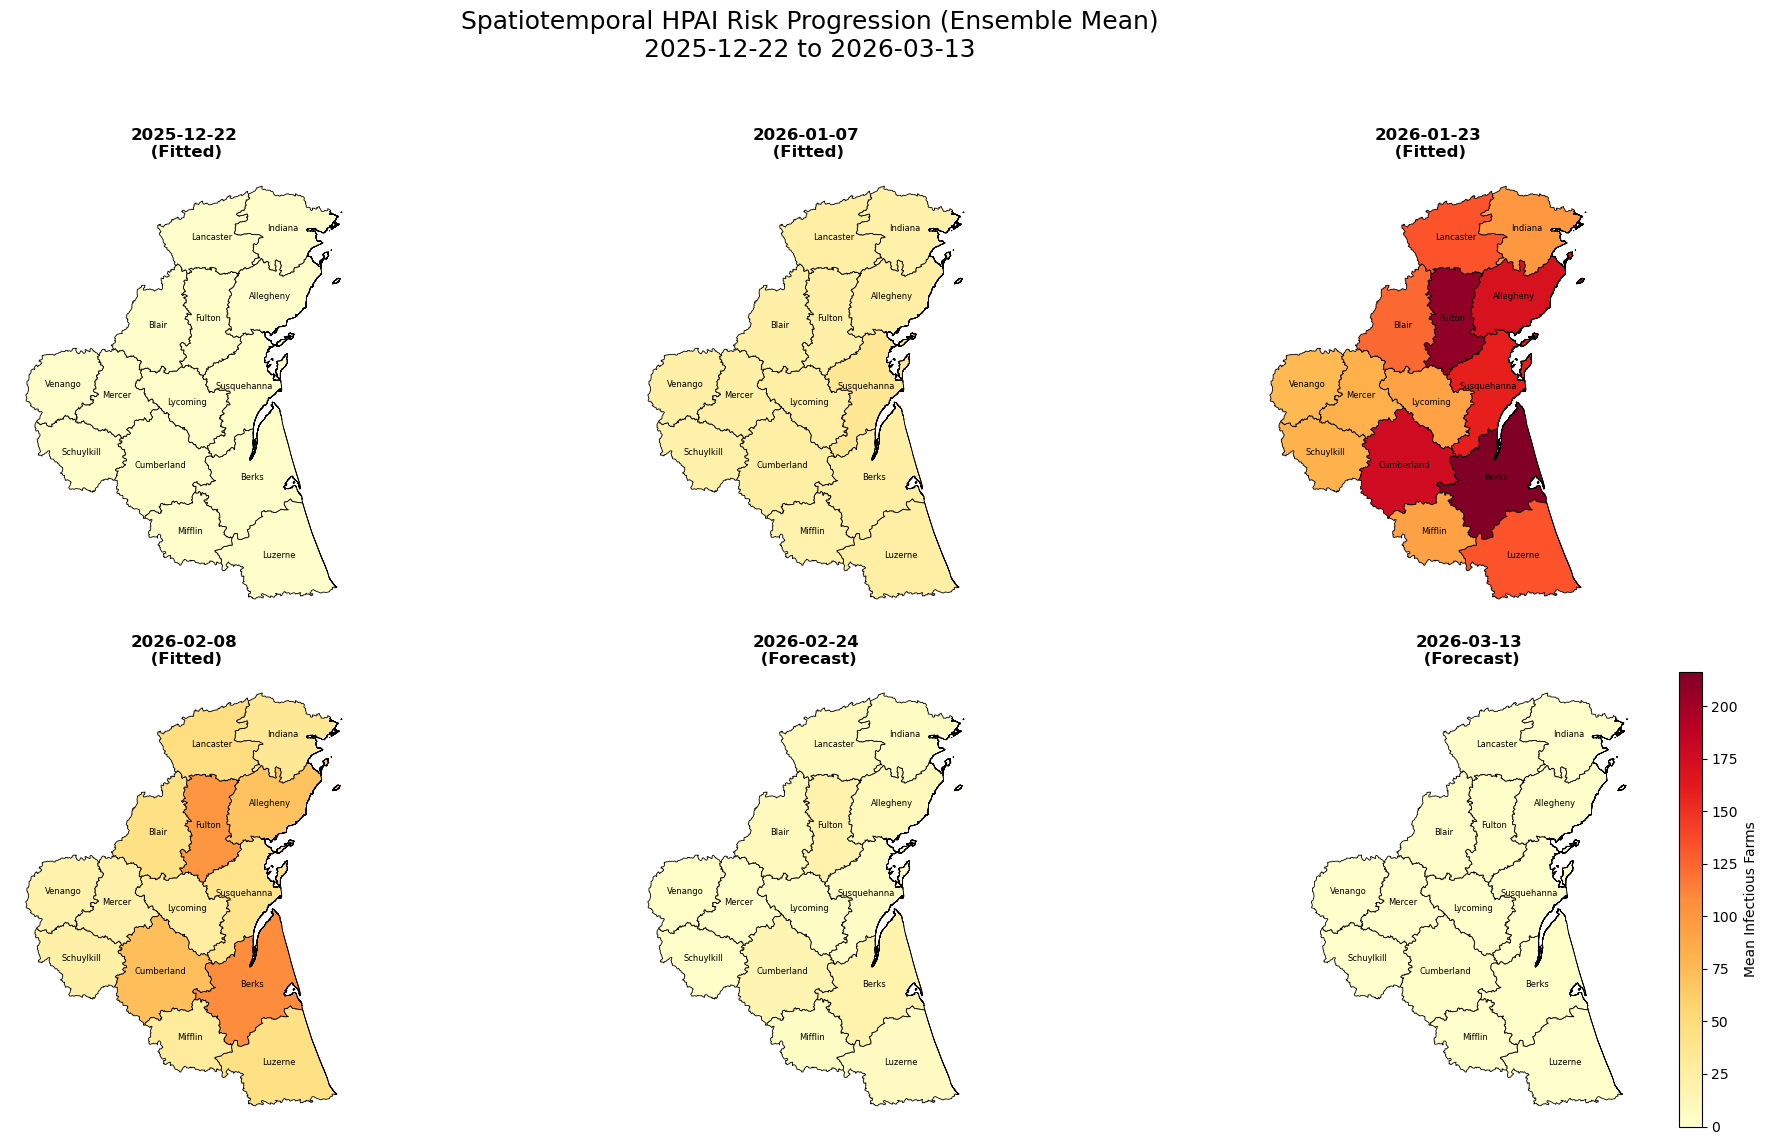

In [22]:
# -------------------------------------------------------------
# [1] Ensemble aggregation: county × day (ENSEMBLE MEAN)
# -------------------------------------------------------------
# ensemble["I"]: (runs, counties, productions, days)

county_daily_mean = ensemble["I"].sum(axis=2).mean(axis=0)  # (counties, days)


# -------------------------------------------------------------
# [2] Snapshot setup
# -------------------------------------------------------------
num_snapshots = 6
indices = np.linspace(0, len(sim_dates) - 1, num_snapshots, dtype=int)

# Load geometry
county_gdf = gpd.read_file("counties_32626.geojson")

# Precompute centroids (safe for labeling)
county_gdf["centroid"] = county_gdf.geometry.centroid
county_gdf["cx"] = county_gdf.centroid.x
county_gdf["cy"] = county_gdf.centroid.y

# Global colour scale for consistency
vmax = county_daily_mean[:, indices].max()


# -------------------------------------------------------------
# [3] Plot multi-panel figure
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, t_idx in enumerate(indices):
    ax = axes[i]

    # County-level data for snapshot
    temp_df = pd.DataFrame({
        "county": counties_vec,
        "inf_farms": county_daily_mean[:, t_idx]
    })

    map_data = county_gdf.merge(
        temp_df,
        on="county",
        how="left"
    ).fillna(0)

    # Choropleth
    map_data.plot(
        column="inf_farms",
        cmap="YlOrRd",
        linewidth=0.6,
        edgecolor="black",
        vmin=0,
        vmax=vmax,
        legend=(i == num_snapshots - 1),
        legend_kwds={"label": "Mean Infectious Farms"},
        ax=ax
    )

    # County labels
    for _, row in map_data.iterrows():
        ax.text(
            row["cx"], row["cy"],
            row["county"],
            fontsize=6,
            ha="center",
            va="center",
            color="black"
        )

    # Title
    title_suffix = " (Forecast)" if sim_dates[t_idx] > fit_end_date else " (Fitted)"
    ax.set_title(
        f"{sim_dates[t_idx].strftime('%Y-%m-%d')}\n{title_suffix}",
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

# -------------------------------------------------------------
# [4] Figure title and export
# -------------------------------------------------------------
plt.suptitle(
    "Spatiotemporal HPAI Risk Progression (Ensemble Mean)\n"
    f"{sim_start_date.date()} to {sim_end_date.date()}",
    fontsize=18
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("spatial_progression_total.png", dpi=300)
plt.show()



In [23]:
# -------------------------------------------------------------
# Save ensemble-mean spatial snapshots as SHP files
# -------------------------------------------------------------
import os

out_dir = "total_shapefiles"
os.makedirs(out_dir, exist_ok=True)

for t_idx in indices:

    snapshot_date = sim_dates[t_idx]
    date_str = snapshot_date.strftime("%Y-%m-%d")

    snapshot_df = pd.DataFrame({
        "county": counties_vec,
        "I_mean": county_daily_mean[:, t_idx]
    })

    snapshot_gdf = county_gdf.merge(
        snapshot_df,
        on="county",
        how="left"
    ).fillna(0)

    # ✅ DROP extra geometry column before saving
    if "centroid" in snapshot_gdf.columns:
        snapshot_gdf = snapshot_gdf.drop(columns=["centroid"])

    snapshot_gdf["date"] = snapshot_date

    shp_path = os.path.join(
        out_dir,
        f"ensemble_mean_{date_str}.shp"
    )

    snapshot_gdf.to_file(shp_path, driver="ESRI Shapefile")

    print(f"Saved {shp_path}")

Saved total_shapefiles\ensemble_mean_2025-12-22.shp
Saved total_shapefiles\ensemble_mean_2026-01-07.shp
Saved total_shapefiles\ensemble_mean_2026-01-23.shp
Saved total_shapefiles\ensemble_mean_2026-02-08.shp
Saved total_shapefiles\ensemble_mean_2026-02-24.shp
Saved total_shapefiles\ensemble_mean_2026-03-13.shp


C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(


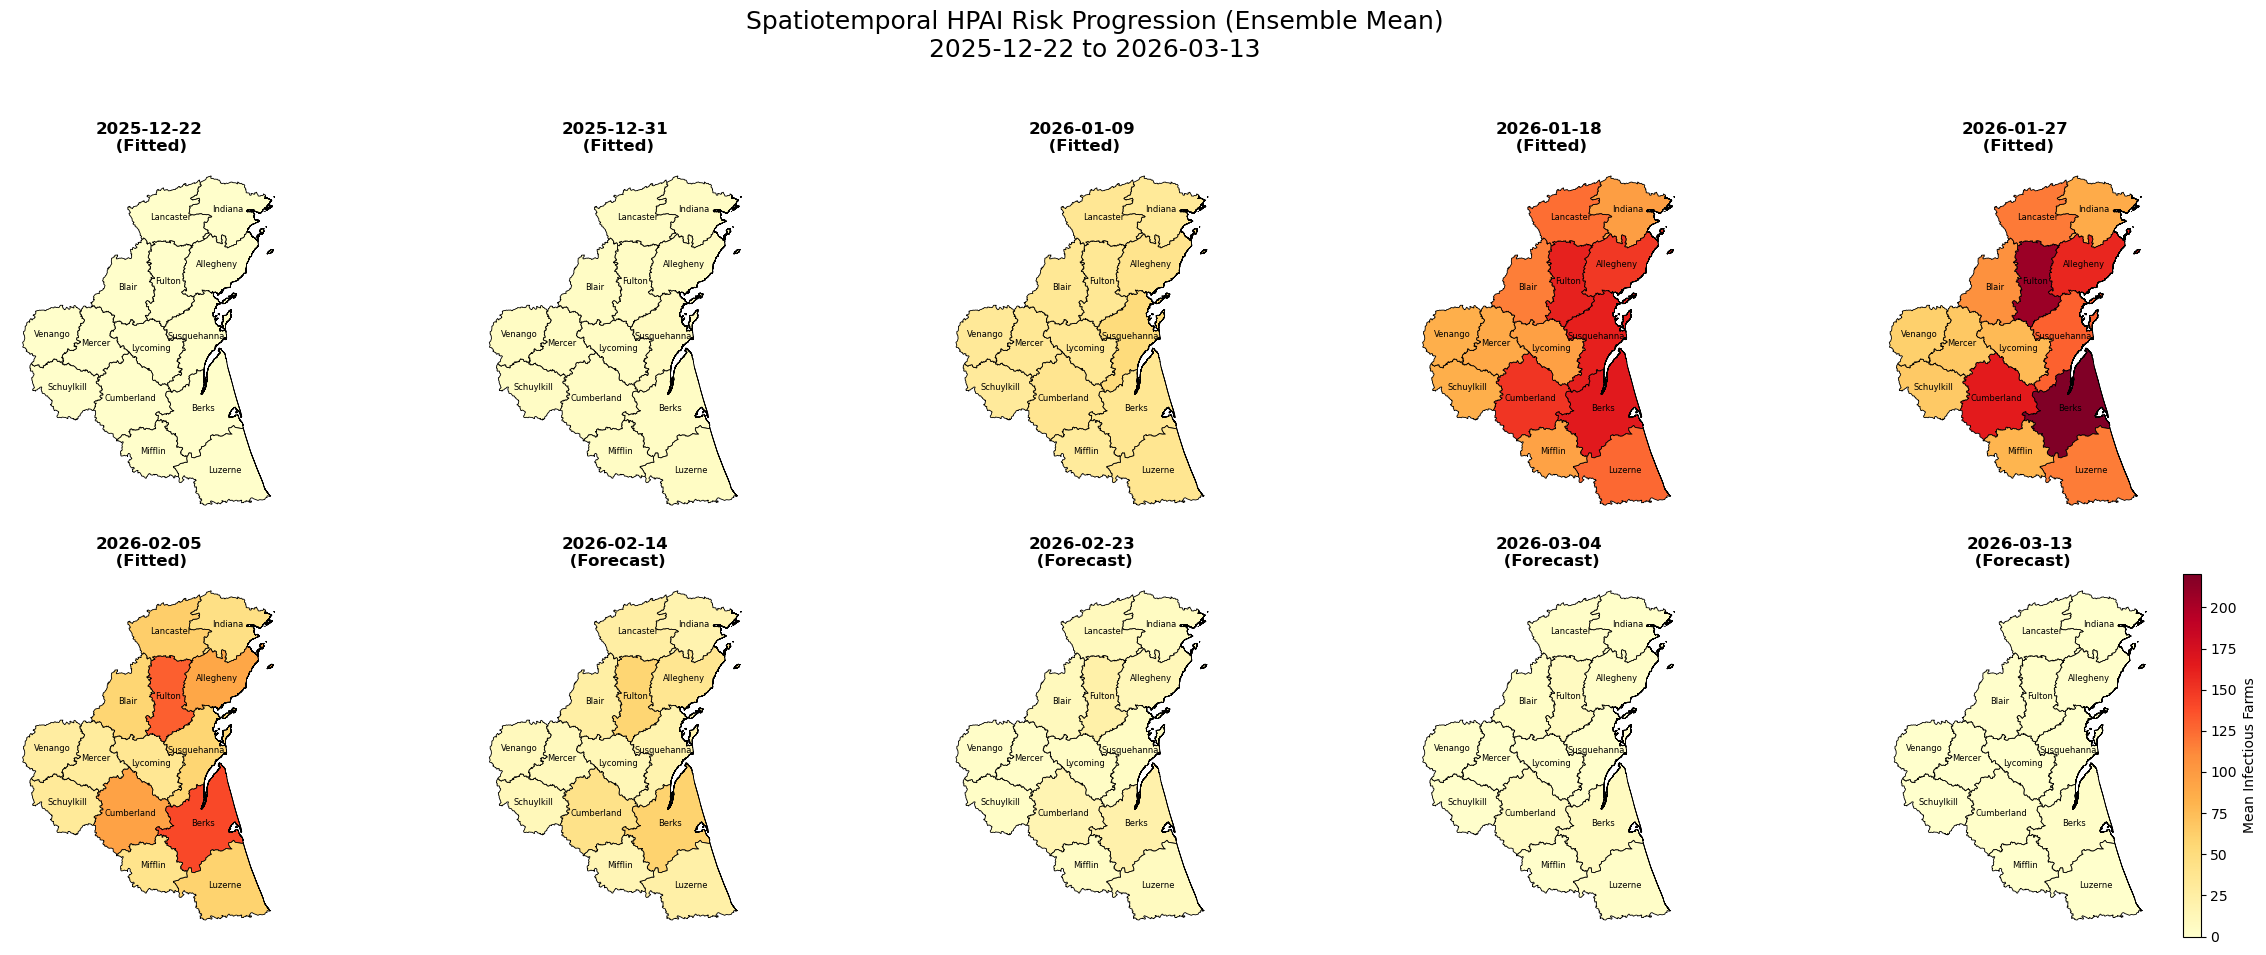

In [24]:
# -------------------------------------------------------------
# [1] Ensemble aggregation: county × day (ENSEMBLE MEAN)
# -------------------------------------------------------------
# ensemble["I"]: (runs, counties, productions, days)

county_daily_mean = ensemble["I"].sum(axis=2).mean(axis=0)  # (counties, days)


# -------------------------------------------------------------
# [2] Snapshot setup (10 panels)
# -------------------------------------------------------------
num_snapshots = 10
indices = np.linspace(0, len(sim_dates) - 1, num_snapshots, dtype=int)

# Load county geometry
county_gdf = gpd.read_file("counties_32626.geojson")

# Compute centroids (safe for labeling; CRS already projected)
county_gdf["centroid"] = county_gdf.geometry.centroid
county_gdf["cx"] = county_gdf.centroid.x
county_gdf["cy"] = county_gdf.centroid.y

# Global color scale for consistency across panels
vmax = county_daily_mean[:, indices].max()


# -------------------------------------------------------------
# [3] Multi-panel spatial figure (2 × 5)
# -------------------------------------------------------------
fig, axes = plt.subplots(
    2, 5,
    figsize=(24, 10),
    constrained_layout=False
)
axes = axes.flatten()

for i, t_idx in enumerate(indices):
    ax = axes[i]

    # County-level data for snapshot
    temp_df = pd.DataFrame({
        "county": counties_vec,
        "inf_farms": county_daily_mean[:, t_idx]
    })

    map_data = county_gdf.merge(
        temp_df,
        on="county",
        how="left"
    ).fillna(0)

    # Choropleth
    map_data.plot(
        column="inf_farms",
        cmap="YlOrRd",
        linewidth=0.6,
        edgecolor="black",
        vmin=0,
        vmax=vmax,
        legend=(i == num_snapshots - 1),
        legend_kwds={"label": "Mean Infectious Farms"},
        ax=ax
    )

    # County labels
    for _, row in map_data.iterrows():
        ax.text(
            row["cx"], row["cy"],
            row["county"],
            fontsize=6,
            ha="center",
            va="center",
            color="black"
        )

    # Panel title
    title_suffix = " (Forecast)" if sim_dates[t_idx] > fit_end_date else " (Fitted)"
    ax.set_title(
        f"{sim_dates[t_idx].strftime('%Y-%m-%d')}\n{title_suffix}",
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")


# -------------------------------------------------------------
# [4] Global title and export
# -------------------------------------------------------------
plt.suptitle(
    "Spatiotemporal HPAI Risk Progression (Ensemble Mean)\n"
    f"{sim_start_date.date()} to {sim_end_date.date()}",
    fontsize=18
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("spatial_progression_total_10panels.png", dpi=300)
plt.show()

In [25]:
# -------------------------------------------------------------
# Save ensemble-mean spatial snapshots as SHP files
# -------------------------------------------------------------


out_dir = "total10_shapefiles"
os.makedirs(out_dir, exist_ok=True)

for t_idx in indices:

    snapshot_date = sim_dates[t_idx]
    date_str = snapshot_date.strftime("%Y-%m-%d")

    snapshot_df = pd.DataFrame({
        "county": counties_vec,
        "I_mean": county_daily_mean[:, t_idx]
    })

    snapshot_gdf = county_gdf.merge(
        snapshot_df,
        on="county",
        how="left"
    ).fillna(0)

    # ✅ DROP extra geometry column before saving
    if "centroid" in snapshot_gdf.columns:
        snapshot_gdf = snapshot_gdf.drop(columns=["centroid"])

    snapshot_gdf["date"] = snapshot_date

    shp_path = os.path.join(
        out_dir,
        f"ensemble_mean_{date_str}.shp"
    )

    snapshot_gdf.to_file(shp_path, driver="ESRI Shapefile")

    print(f"Saved {shp_path}")

C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: Runtime

Saved total10_shapefiles\ensemble_mean_2025-12-22.shp
Saved total10_shapefiles\ensemble_mean_2025-12-31.shp
Saved total10_shapefiles\ensemble_mean_2026-01-09.shp
Saved total10_shapefiles\ensemble_mean_2026-01-18.shp
Saved total10_shapefiles\ensemble_mean_2026-01-27.shp
Saved total10_shapefiles\ensemble_mean_2026-02-05.shp
Saved total10_shapefiles\ensemble_mean_2026-02-14.shp
Saved total10_shapefiles\ensemble_mean_2026-02-23.shp
Saved total10_shapefiles\ensemble_mean_2026-03-04.shp
Saved total10_shapefiles\ensemble_mean_2026-03-13.shp


C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(


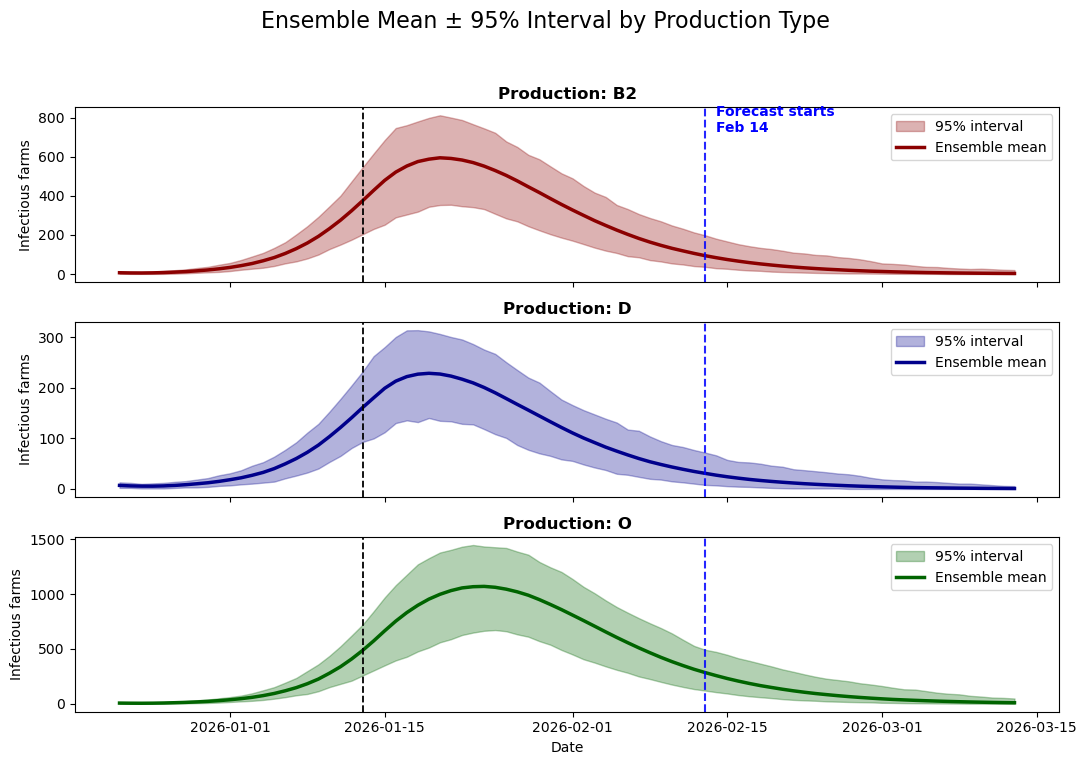

In [26]:
def plot_ensemble_by_production_mean_ci_panels(
    ensemble,
    q=(2.5, 97.5)
):
    """
    Panel plot of ensemble mean ± 95% interval
    for each production type (OPTION A dynamics).
    """

    colors = {
        "B2": "darkred",
        "D":  "darkblue",
        "O":  "darkgreen"
    }

    fig, axes = plt.subplots(
        len(prod_levels), 1,
        figsize=(11, 8),
        sharex=True
    )

    for ax, (p, prod) in zip(axes, enumerate(prod_levels)):

        # Sum over counties → (runs, time)
        I_pt = ensemble["I"][:, :, p, :].sum(axis=1)

        I_mean = I_pt.mean(axis=0)
        I_lo, I_hi = np.percentile(I_pt, q, axis=0)

        ax.fill_between(
            sim_dates,
            I_lo,
            I_hi,
            color=colors[prod],
            alpha=0.3,
            label="95% interval"
        )

        ax.plot(
            sim_dates,
            I_mean,
            color=colors[prod],
            lw=2.5,
            label="Ensemble mean"
        )

        # Confinement
        ax.axvline(
            confinement_start,
            color="black",
            ls="--",
            lw=1.3
        )

        # Forecast start
        ax.axvline(
            fit_end_date,
            color="blue",
            linestyle="--",
            alpha=0.85,
            lw=1.5
        )

        ax.set_ylabel("Infectious farms")
        ax.set_title(f"Production: {prod}", fontsize=12, fontweight="bold")

        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")

    # Forecast annotation once (top-right panel)
    axes[0].text(
        fit_end_date + pd.Timedelta(days=1),
        axes[0].get_ylim()[1] * 0.85,
        "Forecast starts\nFeb 14",
        color="blue",
        fontweight="bold"
    )

    plt.suptitle(
        "Ensemble Mean ± 95% Interval by Production Type",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("Total_Infection_byProduction.png", dpi=300)
    plt.show()

plot_ensemble_by_production_mean_ci_panels(ensemble)

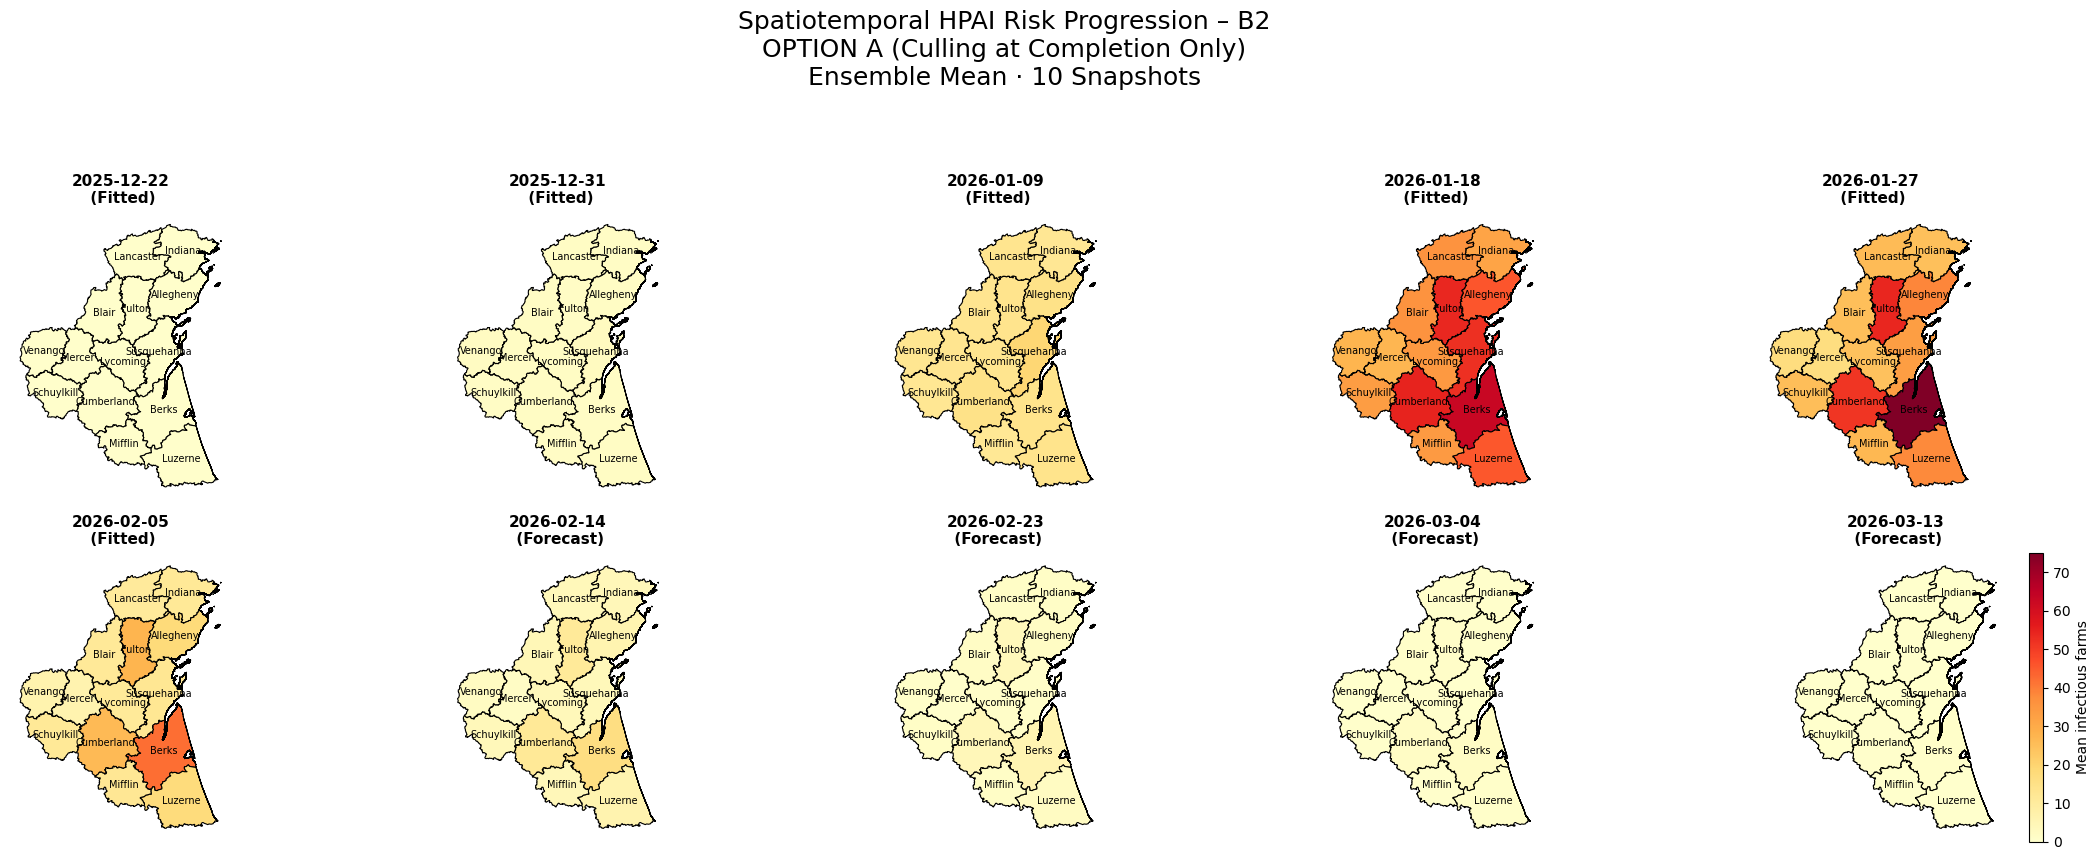

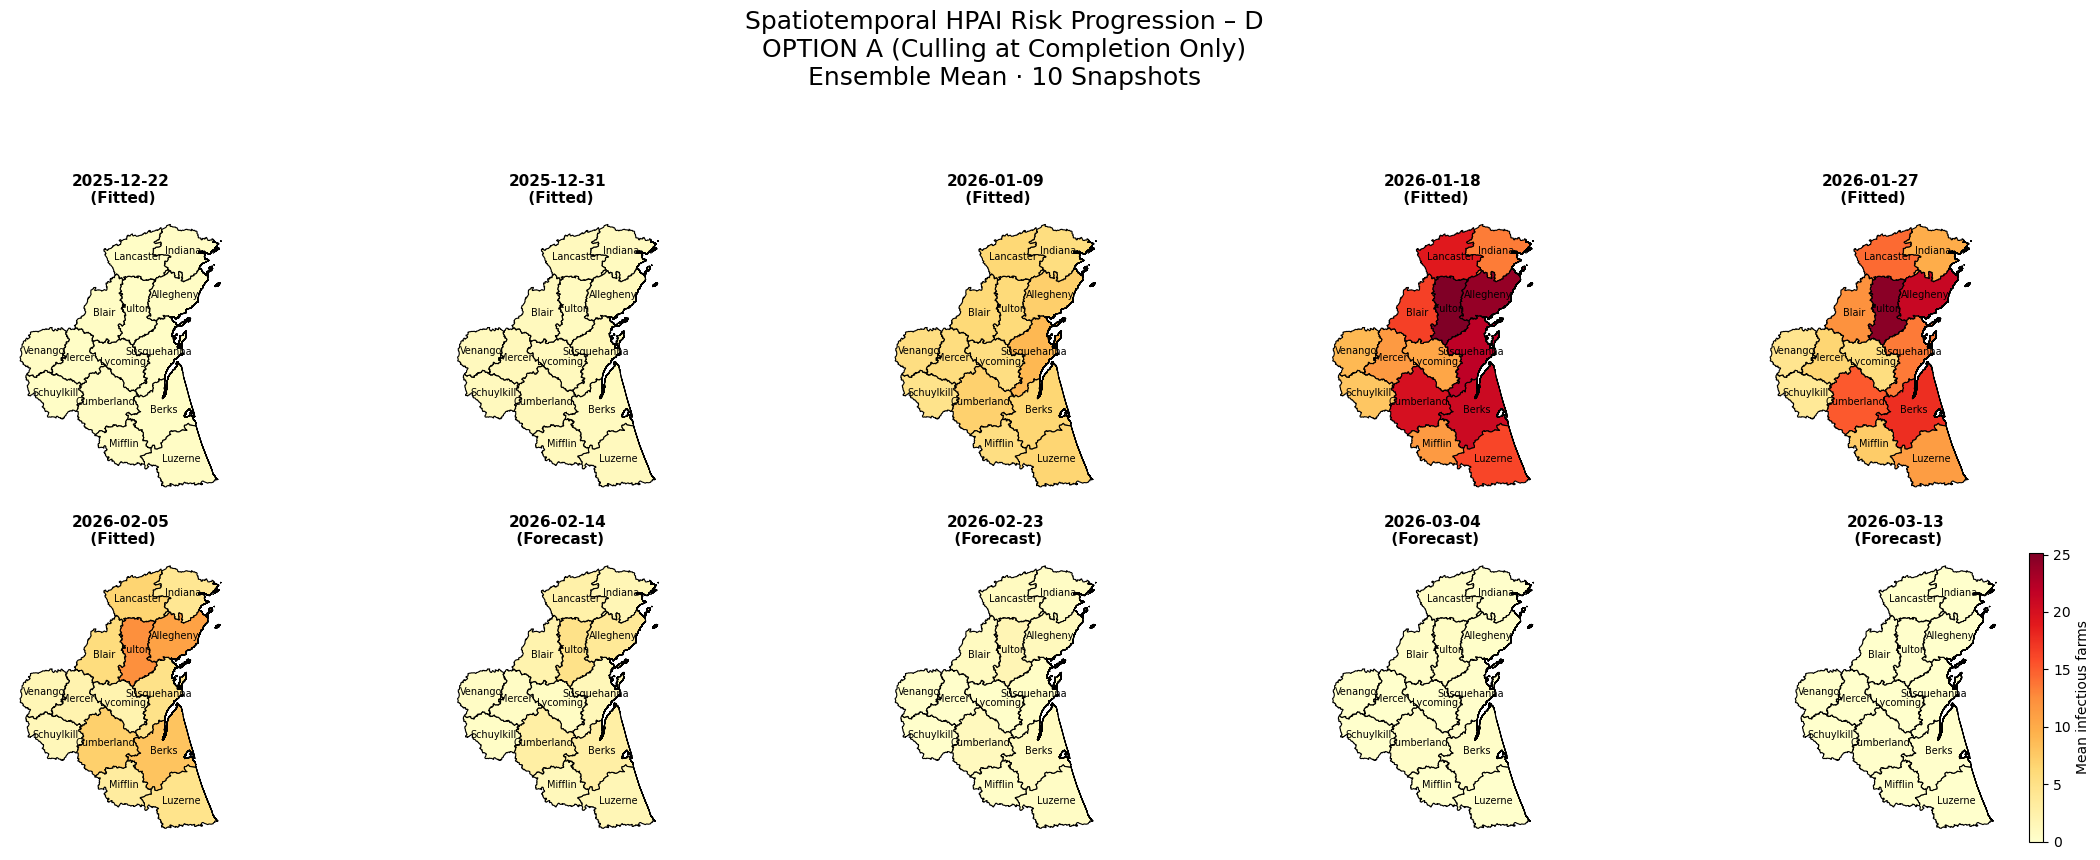

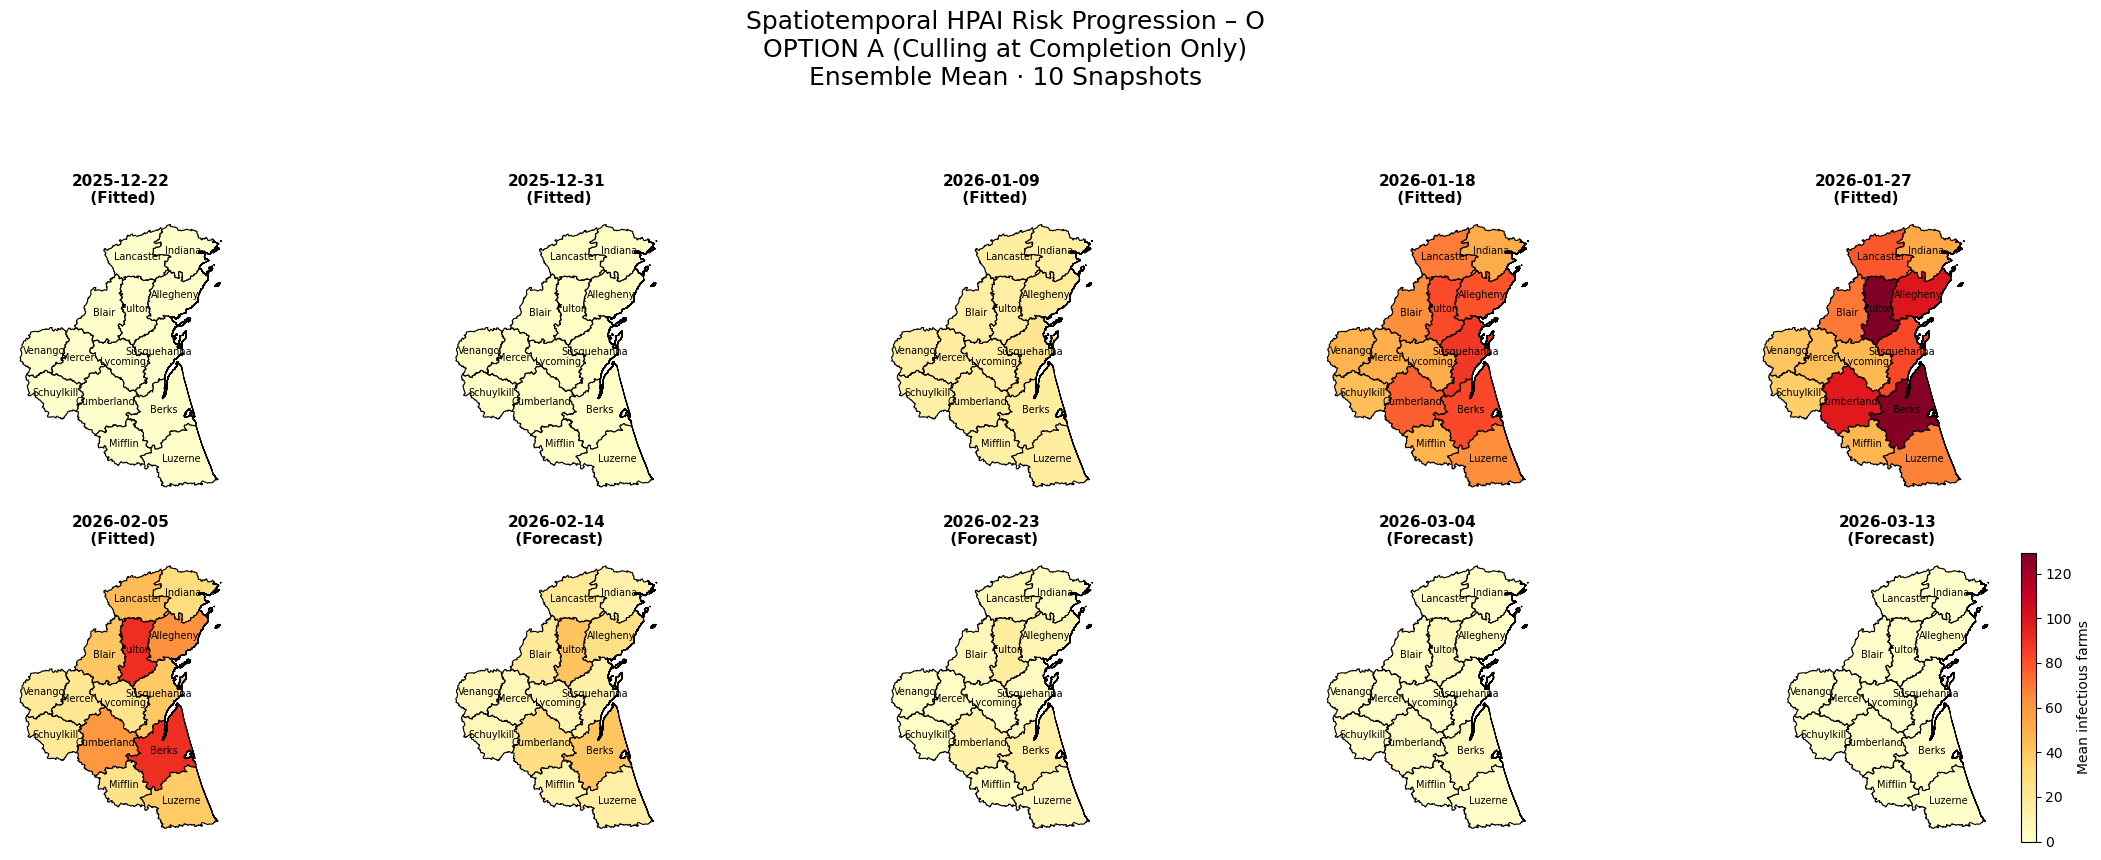

In [27]:
# -------------------------------------------------------------
# OPTION A: Production-specific spatiotemporal maps
# -------------------------------------------------------------

# Load county geometry (once)
county_gdf = gpd.read_file("counties_32626.geojson").copy()

# Precompute centroids (safe for labeling)
county_gdf["centroid"] = county_gdf.geometry.centroid


# Snapshot setup
num_snapshots = 10
indices = np.linspace(0, len(sim_dates) - 1, num_snapshots, dtype=int)

n_cols = 5
n_rows = math.ceil(num_snapshots / n_cols)

for p, prod in enumerate(prod_levels):

    # ---------------------------------------------------------
    # [1] OPTION A ensemble aggregation
    # Mean over runs → (counties × days)
    # ---------------------------------------------------------
    county_daily_mean = ensemble["I"][:, :, p, :].mean(axis=0)

    # Consistent colour scale for this production
    vmax = county_daily_mean[:, indices].max()

    # ---------------------------------------------------------
    # [2] Figure layout
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 4.5 * n_rows)
    )
    axes = axes.flatten()

    for i, t_idx in enumerate(indices):
        ax = axes[i]

        # County-level snapshot
        snapshot_df = pd.DataFrame({
            "county": counties_vec,
            "inf_farms": county_daily_mean[:, t_idx]
        })

        map_data = county_gdf.merge(
            snapshot_df,
            on="county",
            how="left"
        ).fillna(0)

        # -----------------------------------------------------
        # Choropleth (OPTION A dynamics already embedded)
        # -----------------------------------------------------
        map_data.plot(
            column="inf_farms",
            cmap="YlOrRd",
            vmin=0,
            vmax=vmax,
            edgecolor="black",
            linewidth=0.8,
            ax=ax,
            legend=(i == num_snapshots - 1),
            legend_kwds={"label": "Mean infectious farms"}
        )

        # -----------------------------------------------------
        # County labels
        # -----------------------------------------------------
        for _, row in map_data.iterrows():
            ax.text(
                row.centroid.x,
                row.centroid.y,
                row["county"],
                fontsize=7,
                ha="center",
                va="center",
                color="black"
            )

        # -----------------------------------------------------
        # Panel titles
        # -----------------------------------------------------
        title_suffix = " (Forecast)" if sim_dates[t_idx] > fit_end_date else " (Fitted)"
        ax.set_title(
            f"{sim_dates[t_idx].strftime('%Y-%m-%d')}\n{title_suffix}",
            fontsize=11,
            fontweight="bold"
        )

        ax.axis("off")

    # Remove unused panels
    for j in range(num_snapshots, len(axes)):
        fig.delaxes(axes[j])

    # ---------------------------------------------------------
    # [3] Global title and export
    # ---------------------------------------------------------
    plt.suptitle(
        f"Spatiotemporal HPAI Risk Progression – {prod}\n"
        f"OPTION A (Culling at Completion Only)\n"
        f"Ensemble Mean · {num_snapshots} Snapshots",
        fontsize=18
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.savefig(
        f"spatial_progression_{prod}_10.png",
        dpi=300
    )
    plt.show()

In [28]:
# -------------------------------------------------------------
# Save ensemble-mean spatial snapshots as SHP files
# -------------------------------------------------------------
import os

out_dir = "prodtype_shapefiles"
os.makedirs(out_dir, exist_ok=True)

for t_idx in indices:

    snapshot_date = sim_dates[t_idx]
    date_str = snapshot_date.strftime("%Y-%m-%d")

    snapshot_df = pd.DataFrame({
        "county": counties_vec,
        "I_mean": county_daily_mean[:, t_idx]
    })

    snapshot_gdf = county_gdf.merge(
        snapshot_df,
        on="county",
        how="left"
    ).fillna(0)

    # ✅ DROP extra geometry column before saving
    if "centroid" in snapshot_gdf.columns:
        snapshot_gdf = snapshot_gdf.drop(columns=["centroid"])

    snapshot_gdf["date"] = snapshot_date

    shp_path = os.path.join(
        out_dir,
        f"ensemble_mean_{date_str}.shp"
    )

    snapshot_gdf.to_file(shp_path, driver="ESRI Shapefile")

    print(f"Saved {shp_path}")

Saved prodtype_shapefiles\ensemble_mean_2025-12-22.shp
Saved prodtype_shapefiles\ensemble_mean_2025-12-31.shp
Saved prodtype_shapefiles\ensemble_mean_2026-01-09.shp
Saved prodtype_shapefiles\ensemble_mean_2026-01-18.shp
Saved prodtype_shapefiles\ensemble_mean_2026-01-27.shp
Saved prodtype_shapefiles\ensemble_mean_2026-02-05.shp
Saved prodtype_shapefiles\ensemble_mean_2026-02-14.shp
Saved prodtype_shapefiles\ensemble_mean_2026-02-23.shp
Saved prodtype_shapefiles\ensemble_mean_2026-03-04.shp
Saved prodtype_shapefiles\ensemble_mean_2026-03-13.shp


C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
C:\Users\hamme\anaconda3\Lib\site-packages\pyogrio\raw.py:733: Runtime

In [29]:
# Question 4

In [30]:
# -------------------------------------------------
# Confinement strategy:
#   - Confinement ONLY for B2 (chicken farms)
#   - NO confinement for Ducks (D) or Others (O)
# -------------------------------------------------

confinement_start = pd.Timestamp("2026-01-13")

# Reduction in environmental exposure
conf_env_exp = {
    "B2": 0.95,   # confinement applied to chickens
    "D":  1.00,   # no confinement for ducks
    "O":  1.00    # no confinement for others
}

# Reduction in environmental shedding
conf_env_shed = {
    "B2": 0.20,   # strong shedding reduction for chickens
    "D":  1.00,   # no shedding reduction for ducks
    "O":  1.00    # no shedding reduction for others
}

# Reduction in movements
conf_move = {
    "B2": 0.10,   # strong movement restriction for chickens
    "D":  1.00,   # no movement restriction for ducks
    "O":  1.00    # no movement restriction for others
}

In [31]:
beta_w_arr   = np.array([beta_within_p[p] for p in prod_levels])
beta_e_arr   = np.array([beta_env_p[p]    for p in prod_levels])
kappa_e_arr  = np.array([kappa_env_p[p]   for p in prod_levels])
beta_m_arr   = np.array([beta_move_p[p]   for p in prod_levels])

conf_exp_arr  = np.array([conf_env_exp[p]  for p in prod_levels])
conf_shed_arr = np.array([conf_env_shed[p] for p in prod_levels])
conf_move_arr = np.array([conf_move[p]     for p in prod_levels])

In [32]:
def run_ensemble(n_runs=200, base_seed=1234):
    """
    Run an ensemble of stochastic SEIR-B simulations
    using the corrected OPTION A culling logic.
    """
    I_ens = np.zeros((n_runs, C, P, T), dtype=np.int32)
    R_ens = np.zeros_like(I_ens)
    Env_ens = np.zeros((n_runs, C, T), dtype=float)

    for i in range(n_runs):
        out = run_seir_county_prod_realistic(seed=base_seed + i)
        I_ens[i] = out["I"]
        R_ens[i] = out["R"]
        Env_ens[i] = out["Env"]

        if (i + 1) % 20 == 0:
            print(f"Completed run {i + 1}/{n_runs}")

    return {
        "I": I_ens,
        "R": R_ens,
        "Env": Env_ens
    }

ensemble = run_ensemble(n_runs=300, base_seed=2026)

Completed run 20/300
Completed run 40/300
Completed run 60/300
Completed run 80/300
Completed run 100/300
Completed run 120/300
Completed run 140/300
Completed run 160/300
Completed run 180/300
Completed run 200/300
Completed run 220/300
Completed run 240/300
Completed run 260/300
Completed run 280/300
Completed run 300/300


In [33]:
print("Mean final infections:",
      ensemble["I"][:, :, :, -1].sum(axis=(1, 2)).mean())

Mean final infections: 10.393333333333333


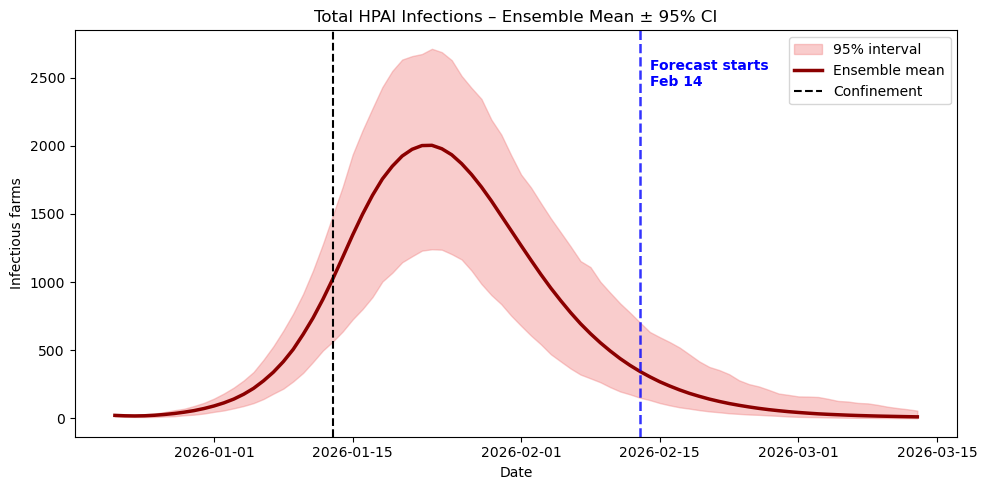

In [34]:
# --- Aggregate total infectious farms over time ---
# ensemble["I"]: (runs, counties, productions, time)

I_total_time = ensemble["I"].sum(axis=(1, 2))  # (runs, time)

I_mean = I_total_time.mean(axis=0)
I_lo = np.percentile(I_total_time, 2.5, axis=0)
I_hi = np.percentile(I_total_time, 97.5, axis=0)


# --- Plot ---
plt.figure(figsize=(10, 5))

plt.fill_between(
    sim_dates,
    I_lo,
    I_hi,
    color="lightcoral",
    alpha=0.4,
    label="95% interval"
)

plt.plot(
    sim_dates,
    I_mean,
    color="darkred",
    lw=2.5,
    label="Ensemble mean"
)

# Confinement
plt.axvline(
    confinement_start,
    color="black",
    linestyle="--",
    lw=1.5,
    label="Confinement"
)

# Forecast start (fit end)
plt.axvline(
    fit_end_date,
    color="blue",
    linestyle="--",
    alpha=0.8,
    lw=1.8
)

# Annotation
plt.text(
    fit_end_date + pd.Timedelta(days=1),
    I_hi.max() * 0.9,
    "Forecast starts\nFeb 14",
    color="blue",
    fontweight="bold"
)

plt.ylabel("Infectious farms")
plt.xlabel("Date")
plt.title("Total HPAI Infections – Ensemble Mean ± 95% CI")

plt.legend()
plt.tight_layout()
plt.savefig("Total_Infection_D.png", dpi=300)
plt.show()

In [35]:
# Index and date of maximum
I_mean = I_mean.max()
date_peak = sim_dates[t_peak]

print("Peak mean infections:", I_mean)
print("Date of peak:", date_peak)

NameError: name 't_peak' is not defined

In [ ]:
def plot_ensemble_by_production_mean_ci_panels(
    ensemble,
    q=(2.5, 97.5)
):
    """
    Panel plot of ensemble mean ± 95% interval
    for each production type (OPTION A dynamics).
    """

    colors = {
        "B2": "darkred",
        "D":  "darkblue",
        "O":  "darkgreen"
    }

    fig, axes = plt.subplots(
        len(prod_levels), 1,
        figsize=(11, 8),
        sharex=True
    )

    for ax, (p, prod) in zip(axes, enumerate(prod_levels)):

        # Sum over counties → (runs, time)
        I_pt = ensemble["I"][:, :, p, :].sum(axis=1)

        I_mean = I_pt.mean(axis=0)
        I_lo, I_hi = np.percentile(I_pt, q, axis=0)

        ax.fill_between(
            sim_dates,
            I_lo,
            I_hi,
            color=colors[prod],
            alpha=0.3,
            label="95% interval"
        )

        ax.plot(
            sim_dates,
            I_mean,
            color=colors[prod],
            lw=2.5,
            label="Ensemble mean"
        )

        # Confinement
        ax.axvline(
            confinement_start,
            color="black",
            ls="--",
            lw=1.3
        )

        # Forecast start
        ax.axvline(
            fit_end_date,
            color="blue",
            linestyle="--",
            alpha=0.85,
            lw=1.5
        )

        ax.set_ylabel("Infectious farms")
        ax.set_title(f"Production: {prod}", fontsize=12, fontweight="bold")

        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")

    # Forecast annotation once (top-right panel)
    axes[0].text(
        fit_end_date + pd.Timedelta(days=1),
        axes[0].get_ylim()[1] * 0.85,
        "Forecast starts\nFeb 14",
        color="blue",
        fontweight="bold"
    )

    plt.suptitle(
        "Ensemble Mean ± 95% Interval by Production Type",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("Total_Infection_Prod_D.png", dpi=300)
    plt.show()

plot_ensemble_by_production_mean_ci_panels(ensemble)

In [ ]:
# -------------------------------------------------
# Confinement strategy:
#   - NO confinement for ANY production type
#   - Reactive culling only (OPTION A)
# -------------------------------------------------

confinement_start = pd.Timestamp("2026-01-13")  # retained for compatibility

# No reduction in environmental exposure
conf_env_exp = {
    "B2": 1.00,
    "D":  1.00,
    "O":  1.00
}

# No reduction in environmental shedding
conf_env_shed = {
    "B2": 1.00,
    "D":  1.00,
    "O":  1.00
}

# No reduction in movements
conf_move = {
    "B2": 1.00,
    "D":  1.00,
    "O":  1.00
}

In [ ]:
def run_ensemble(n_runs=200, base_seed=1234):
    """
    Run an ensemble of stochastic SEIR-B simulations
    using the corrected OPTION A culling logic.
    """
    I_ens = np.zeros((n_runs, C, P, T), dtype=np.int32)
    R_ens = np.zeros_like(I_ens)
    Env_ens = np.zeros((n_runs, C, T), dtype=float)

    for i in range(n_runs):
        out = run_seir_county_prod_realistic(seed=base_seed + i)
        I_ens[i] = out["I"]
        R_ens[i] = out["R"]
        Env_ens[i] = out["Env"]

        if (i + 1) % 20 == 0:
            print(f"Completed run {i + 1}/{n_runs}")

    return {
        "I": I_ens,
        "R": R_ens,
        "Env": Env_ens
    }

ensemble = run_ensemble(n_runs=300, base_seed=2026)

In [ ]:
print("Mean final infections:",
      ensemble["I"][:, :, :, -1].sum(axis=(1, 2)).mean())

In [ ]:
# --- Aggregate total infectious farms over time ---
# ensemble["I"]: (runs, counties, productions, time)

I_total_time = ensemble["I"].sum(axis=(1, 2))  # (runs, time)

I_mean = I_total_time.mean(axis=0)
I_lo = np.percentile(I_total_time, 2.5, axis=0)
I_hi = np.percentile(I_total_time, 97.5, axis=0)


# --- Plot ---
plt.figure(figsize=(10, 5))

plt.fill_between(
    sim_dates,
    I_lo,
    I_hi,
    color="lightcoral",
    alpha=0.4,
    label="95% interval"
)

plt.plot(
    sim_dates,
    I_mean,
    color="darkred",
    lw=2.5,
    label="Ensemble mean"
)

# Confinement
plt.axvline(
    confinement_start,
    color="black",
    linestyle="--",
    lw=1.5,
    label="Confinement"
)

# Forecast start (fit end)
plt.axvline(
    fit_end_date,
    color="blue",
    linestyle="--",
    alpha=0.8,
    lw=1.8
)

# Annotation
plt.text(
    fit_end_date + pd.Timedelta(days=1),
    I_hi.max() * 0.9,
    "Forecast starts\nFeb 14",
    color="blue",
    fontweight="bold"
)

plt.ylabel("Infectious farms")
plt.xlabel("Date")
plt.title("Total HPAI Infections – Ensemble Mean ± 95% CI")

plt.legend()
plt.tight_layout()
plt.savefig("Total_Infection_all.png", dpi=300)
plt.show()

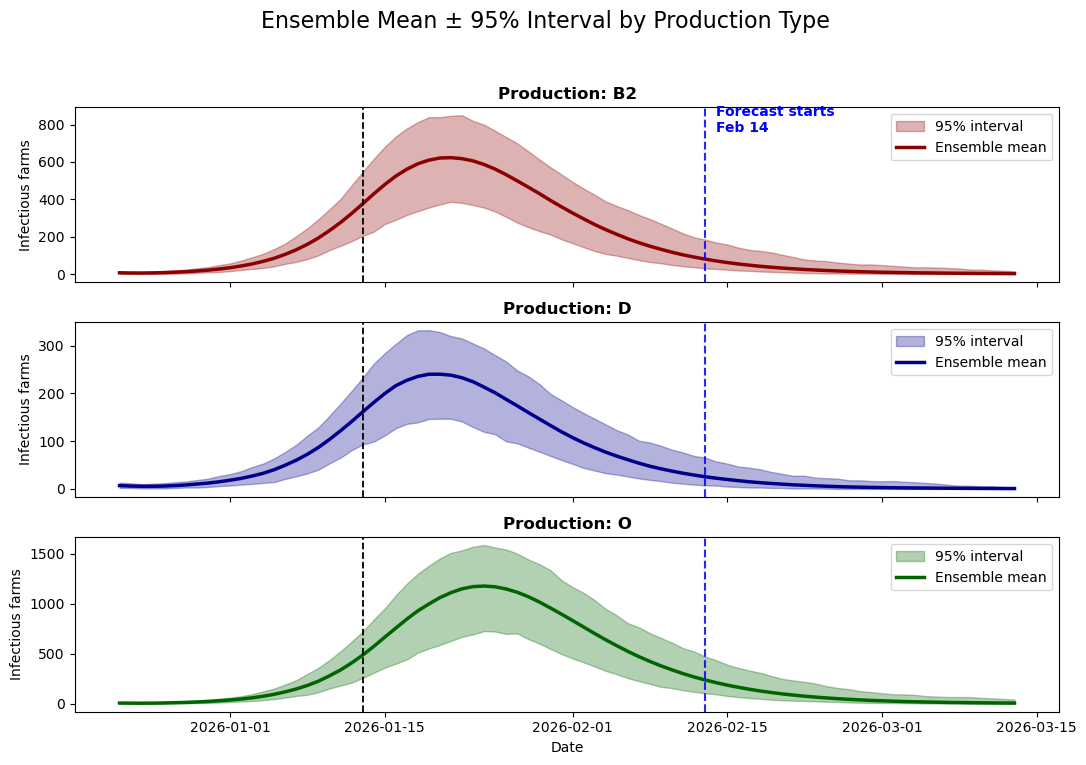

In [36]:
def plot_ensemble_by_production_mean_ci_panels(
    ensemble,
    q=(2.5, 97.5)
):
    """
    Panel plot of ensemble mean ± 95% interval
    for each production type (OPTION A dynamics).
    """

    colors = {
        "B2": "darkred",
        "D":  "darkblue",
        "O":  "darkgreen"
    }

    fig, axes = plt.subplots(
        len(prod_levels), 1,
        figsize=(11, 8),
        sharex=True
    )

    for ax, (p, prod) in zip(axes, enumerate(prod_levels)):

        # Sum over counties → (runs, time)
        I_pt = ensemble["I"][:, :, p, :].sum(axis=1)

        I_mean = I_pt.mean(axis=0)
        I_lo, I_hi = np.percentile(I_pt, q, axis=0)

        ax.fill_between(
            sim_dates,
            I_lo,
            I_hi,
            color=colors[prod],
            alpha=0.3,
            label="95% interval"
        )

        ax.plot(
            sim_dates,
            I_mean,
            color=colors[prod],
            lw=2.5,
            label="Ensemble mean"
        )

        # Confinement
        ax.axvline(
            confinement_start,
            color="black",
            ls="--",
            lw=1.3
        )

        # Forecast start
        ax.axvline(
            fit_end_date,
            color="blue",
            linestyle="--",
            alpha=0.85,
            lw=1.5
        )

        ax.set_ylabel("Infectious farms")
        ax.set_title(f"Production: {prod}", fontsize=12, fontweight="bold")

        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")

    # Forecast annotation once (top-right panel)
    axes[0].text(
        fit_end_date + pd.Timedelta(days=1),
        axes[0].get_ylim()[1] * 0.85,
        "Forecast starts\nFeb 14",
        color="blue",
        fontweight="bold"
    )

    plt.suptitle(
        "Ensemble Mean ± 95% Interval by Production Type",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("Total_Infection_Prod_all.png", dpi=300)
    plt.show()

plot_ensemble_by_production_mean_ci_panels(ensemble)